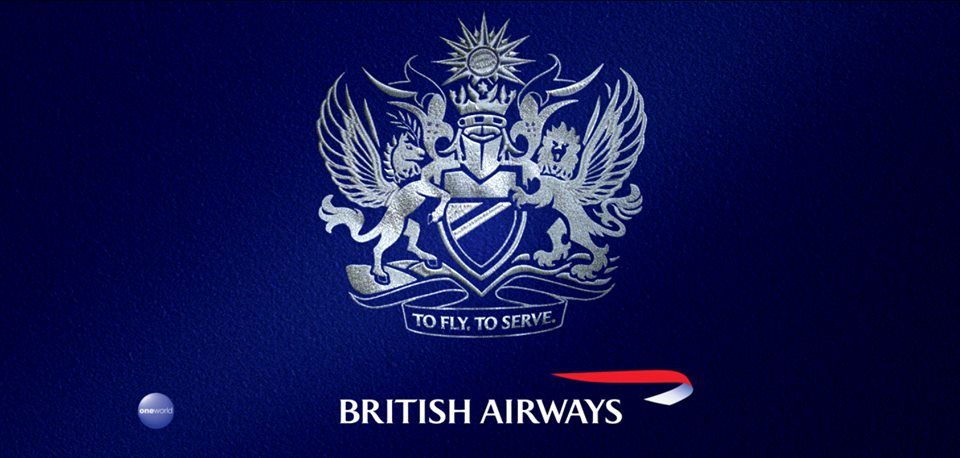

# British Airways - Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style = "whitegrid", palette = "muted")
plt.rcParams["figure.dpi"] = 130

We import all libraries beforehand:

- `pandas / numpy`: data wrangling
- `sklearn`: ML pipeline (model, metrics, cross-validation)
- `matplotlib / seaborn`: visualization
- `warnings`: suppress noisy deprecation warnings

In here, the key is `StratifiedKFold` becuase it ensures each fold has the same class ratio, which matters when your target is imbalanced (more non-bookers than bookers).

In [15]:
data = pd.read_csv("/content/customer_booking.csv", encoding = "ISO-8859-1")
data_copy = data.copy()

data.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [14]:
data.shape

(50000, 14)

The `.shape` attribute returns a tuple representing the dimensions of the dataset in the format *(rows, columns)*. This is useful for immediately understanding the scale of your data.

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [17]:
data.isnull().sum()

,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


The `.isnull()` method scans every cell in the DataFrame and returns a new DataFrame of the same shape filled with boolean values. Chaining `.sum()` on top of that then collapses each column down to a single number by counting how many True values it contains, since Python treats True as 1 and False as 0 internally. This is useful for getting a column-by-column count of missing values in one clean output, so you can immediately see which features have gaps in the data and decide how to handle them

In [6]:
data["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [7]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

data["flight_day"] = data["flight_day"].map(mapping)

In [11]:
data["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [12]:
data.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [22]:
print(data["booking_complete"].value_counts())
print("-" * 25)
print(data["booking_complete"].value_counts(normalize = True).round(3))

booking_complete
0    42522
1     7478
Name: count, dtype: int64
-------------------------
booking_complete
0    0.85
1    0.15
Name: proportion, dtype: float64


As you can see, there is a heavily imbalanced target **85/15** which means accuracy alone is a useless metric. Therefore, we'll use F1 and AUC instead.

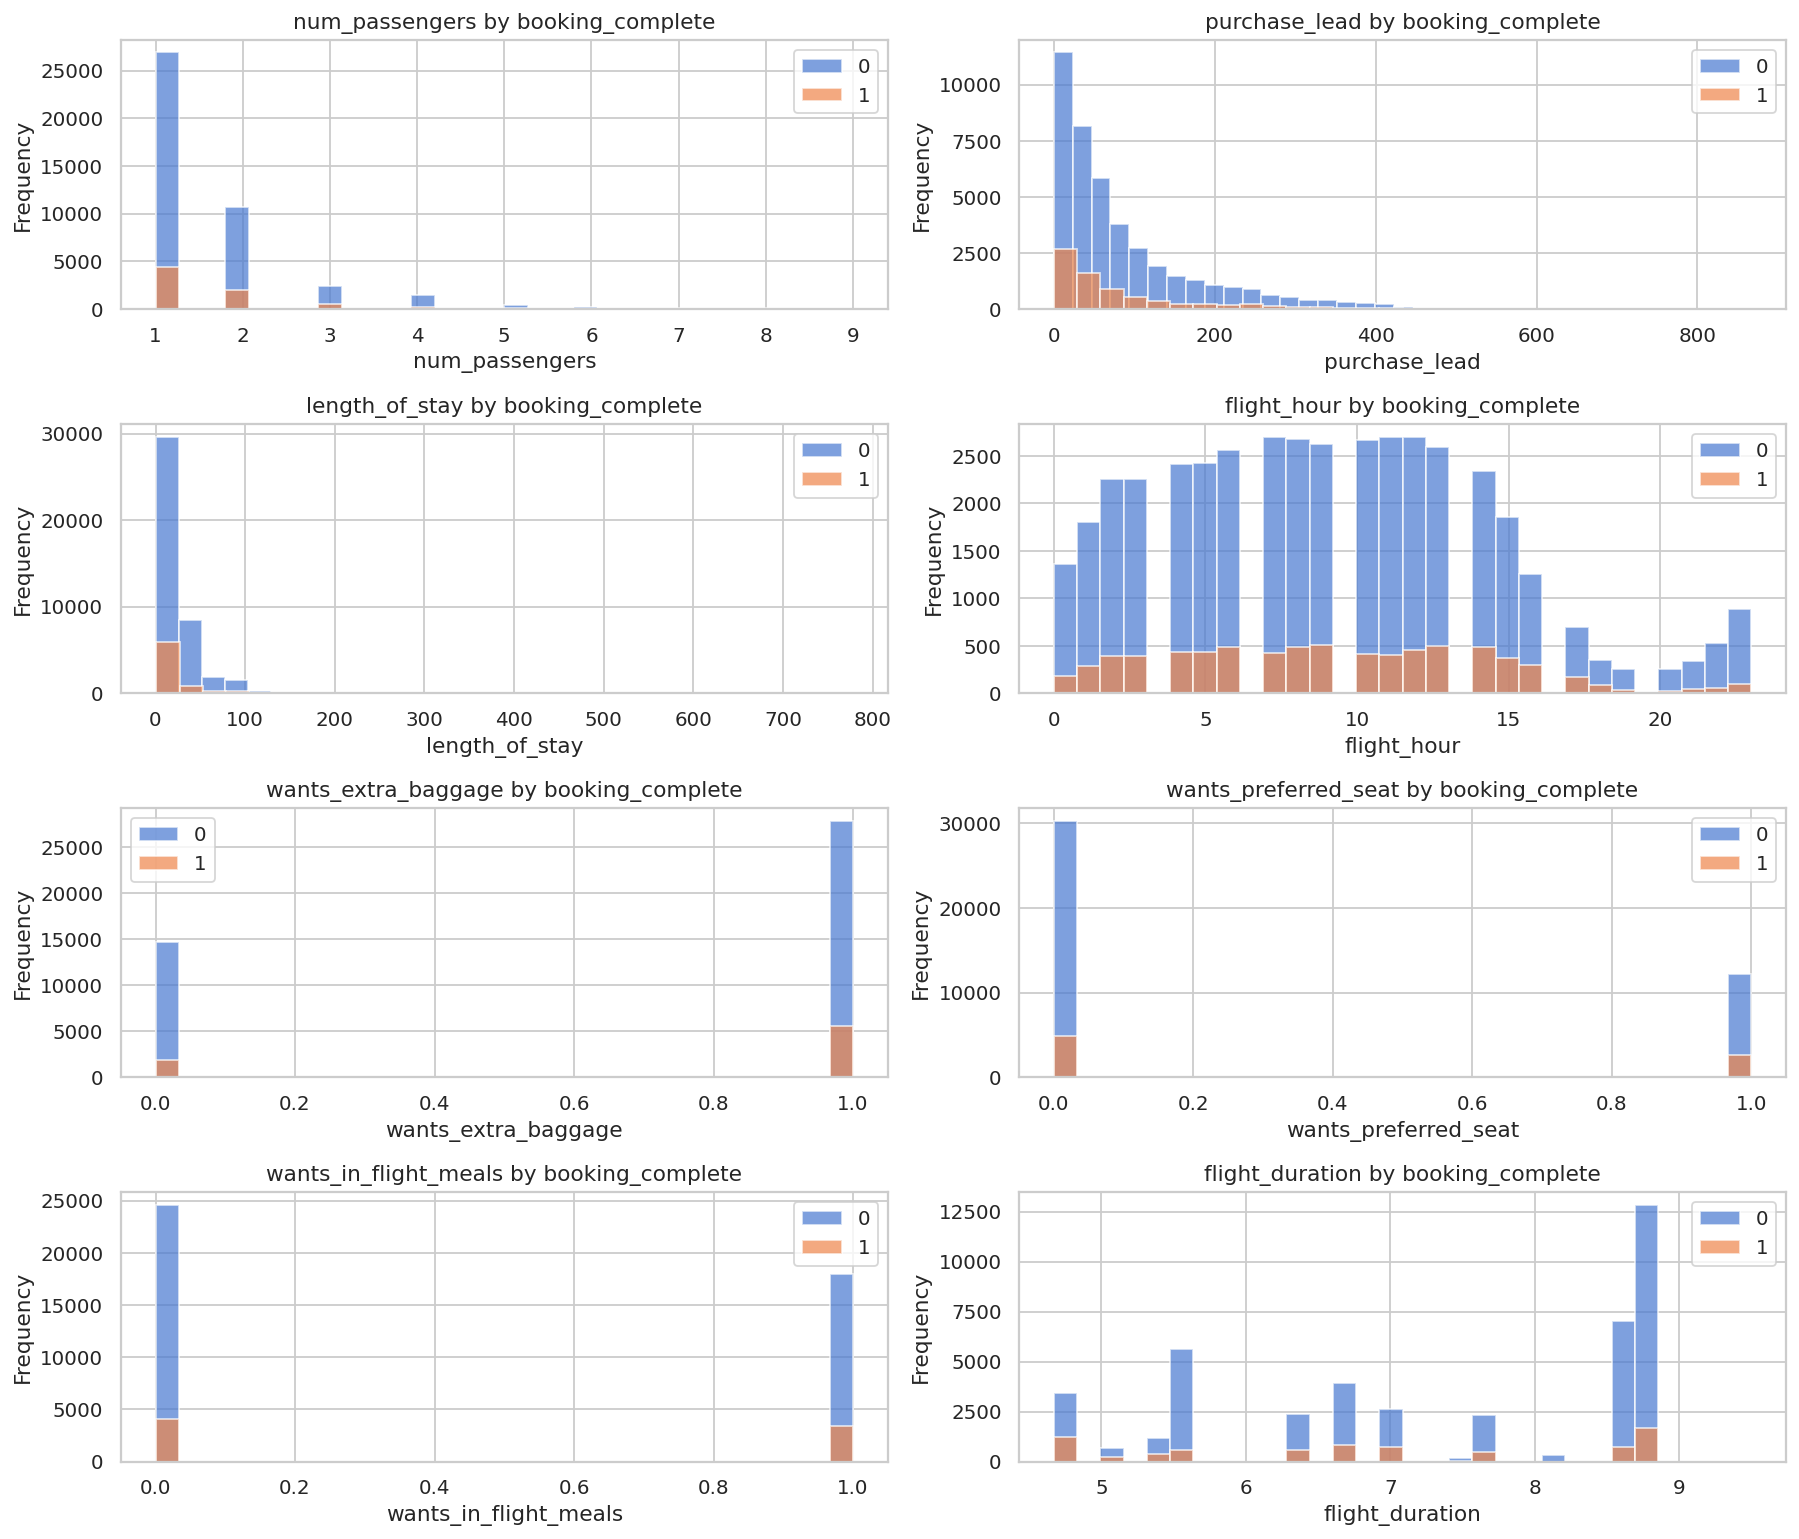

In [38]:
# Numeric columns
numeric_cols = data.select_dtypes(include = np.number).columns.tolist() # 8
numeric_cols.remove("booking_complete") # remove target

fig, axes = plt.subplots(nrows = 4, ncols = 2, figsize = (14, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[ : 8]):
    data.groupby("booking_complete")[col].plot(kind = "hist", bins = 30, alpha = 0.7, ax=axes[i], legend = True)
    axes[i].set_title(f"{col} by booking_complete")
    axes[i].set_xlabel(col)

# Numeric Feature Distributions by Target
plt.tight_layout()
plt.show()

In [41]:
# Categorical

cat_cols = data.select_dtypes(include = "object").columns.tolist() # 5

for col in cat_cols:
    rate = df.groupby(col)["booking_complete"].mean().sort_values(ascending = False)
    print("-" * 50)
    print(f"\n--- Booking Rate by {col} ---")
    print(rate.round(3))

--------------------------------------------------

--- Booking Rate by sales_channel ---
sales_channel
Internet    0.155
Mobile      0.108
Name: booking_complete, dtype: float64
--------------------------------------------------

--- Booking Rate by trip_type ---
trip_type
RoundTrip     0.151
OneWay        0.052
CircleTrip    0.043
Name: booking_complete, dtype: float64
--------------------------------------------------

--- Booking Rate by flight_day ---
flight_day
Wed    0.163
Thu    0.151
Mon    0.149
Sat    0.148
Tue    0.147
Fri    0.145
Sun    0.141
Name: booking_complete, dtype: float64
--------------------------------------------------

--- Booking Rate by route ---
route
AORPER    1.0
MELNRT    1.0
KOSSYD    1.0
KCHMRU    1.0
KTMURT    1.0
         ... 
HNDOOL    0.0
HNDMLE    0.0
HNDMAA    0.0
HNDLOP    0.0
KNOKTM    0.0
Name: booking_complete, Length: 799, dtype: float64
--------------------------------------------------

--- Booking Rate by booking_origin ---
booking_origi

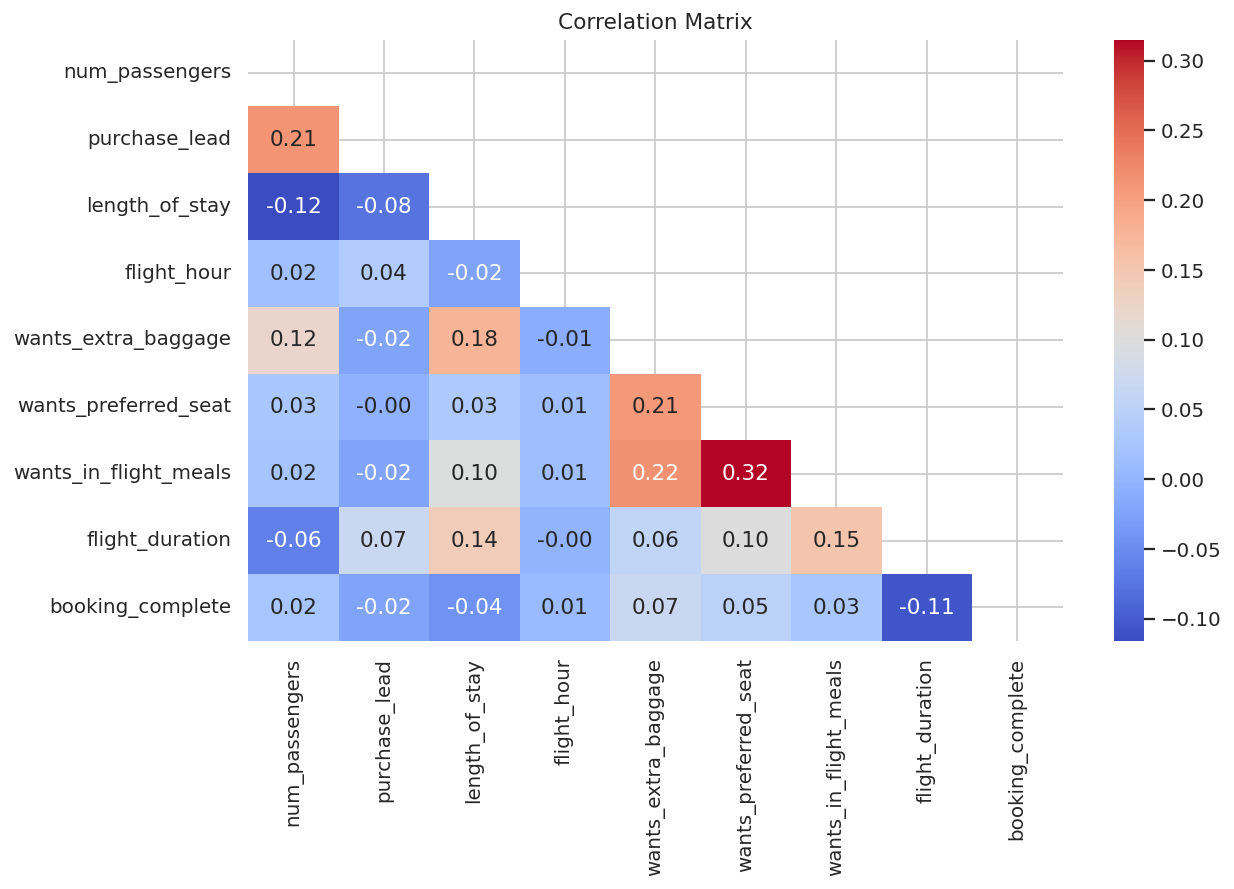

In [50]:
# Correlation heatmap

plt.figure(figsize = (10, 7))
corr = data[numeric_cols + ["booking_complete"]].corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, mask = mask, annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In the end of EDA, we just try to find answers for questions like "which features actually differ between people who booked and those who didn't?" becuase visually strong separation means strong predictor too.

Lastly, the correlation heatmap shows linear relationships, but RandomForest will catch non-linear ones too.

## Feauture engineering


In [55]:
# Feature 1: How early before the flight was the booking made?
data["purchase_urgency"] = pd.cut(
    data["purchase_lead"], bins = [0, 7, 30, 90, 365, 9999],
    labels=["last_minute", "short", "medium", "long", "very_long"]
    )

# Feature 2: Total optional extras selected (proxy for intent / commitment)
extra_cols = ["wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals"]
data["total_extras"] = data[extra_cols].sum(axis = 1)

# Feature 3: Is this a long-haul flight? (>6 hours)
data["is_long_haul"] = (data["flight_duration"] > 6).astype(int)

# Feature 4: Is the flight over the weekend?
day_map = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3, "Fri": 4, "Sat": 5, "Sun": 6}

if data["flight_day"].dtype == object:
  data["flight_day_num"] = data["flight_day"].map(day_map)

data["is_weekend_flight"] = data["flight_day_num"].apply(
    lambda x: 1 if x >= 4 else 0)

# Feature 5: Booking made in business hours? (8am - 6pm)
data["is_business_hours"] = data["flight_hour"].apply(
    lambda x: 1 if 8 <= x <= 18 else 0)

# ---
new_feats = ["purchase_urgency", "total_extras", "is_long_haul",
             "is_weekend_flight", "is_business_hours"]
display(data[new_feats].head(10))

,purchase_urgency,total_extras,is_long_haul,is_weekend_flight,is_business_hours
0,long,1,0,1,0
1,long,0,0,1,0
2,long,2,0,0,1
3,long,1,0,1,0
4,medium,2,0,0,1
5,last_minute,2,0,0,0
6,long,2,0,0,0
7,long,2,0,0,1
8,medium,1,0,0,0
9,very_long,0,0,1,1


In this stage, the `total_extras` is a strong signal for us becuase it indicates a customer who wants a preferred seat AND extra baggage AND meals is far more likely to complete the booking than someone who wants nothing.

## Encoding

In [61]:
data_processed = data.copy()

# Label encode all object and category columns
label_encoders = { }
for col in data_processed.select_dtypes(include = ["object", "category"]).columns:
    le = LabelEncoder()
    data_processed[col] = le.fit_transform(data_processed[col].astype(str))
    label_encoders[col] = le  # Save encoder in case we need to decode later

# Split data into features (x) and target (y)
x = data_processed.drop(columns = ["booking_complete"])
y = data_processed["booking_complete"]

Initially, `RandomForest` requires numeric input only. Hence, we encode all string/categorical columns to integers. Then, split our data into x and y for making it ready for training stage.

In [63]:
rf_model = RandomForestClassifier(
    n_estimators = 200, # Number of trees
    max_depth = 10, # Prevent overfitting by limiting tree depth
    min_samples_leaf = 10, # Each leaf must have ≥10 samples (regularization)
    class_weight = "balanced", # Compensate for class imbalance automatically
    random_state = 42, # Reproducibility
    n_jobs = -1 # Use all CPU cores
)

# Train (we'll properly evaluate with cross-validation next)
rf_model.fit(x, y)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [67]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 0)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall"
}

cv_results = cross_validate(
    rf_model, x, y, cv = cv, scoring = scoring, return_train_score = True
)

# Display results as a clean summary table
metrics_data = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Train Mean": [cv_results[f"train_{m}"].mean().round(4) for m in scoring],
    "Val Mean": [cv_results[f"test_{m}"].mean().round(4) for m in scoring],
    "Val Std": [cv_results[f"test_{m}"].std().round(4) for m in scoring],
})

display(metrics_data)

print("-" * 40)
for m in scoring:
    diff = cv_results[f"train_{m}"].mean() - cv_results[f"test_{m}"].mean()
    flag = "Overfit" if diff > 0.1 else "Normal"
    print(f"{m:10s}: {diff:+.3f} - {flag}")

,Metric,Train Mean,Val Mean,Val Std
0,accuracy,0.7325,0.7059,0.0072
1,f1,0.4700,0.4143,0.0056
2,roc_auc,0.8298,0.7640,0.0075
3,precision,0.3340,0.2951,0.0055
4,recall,0.7932,0.6951,0.0104


----------------------------------------
accuracy  : +0.027 - Normal
f1        : +0.056 - Normal
roc_auc   : +0.066 - Normal
precision : +0.039 - Normal
recall    : +0.098 - Normal


We use 5-fold Stratified CV, this is the correct way to evaluate. Becuase train/test split once is unreliable, while CV gives 5 independent evaluations.

Moreover, we can check for overfitting. Basically, big gap between `Train` and `Val` means overfitting.

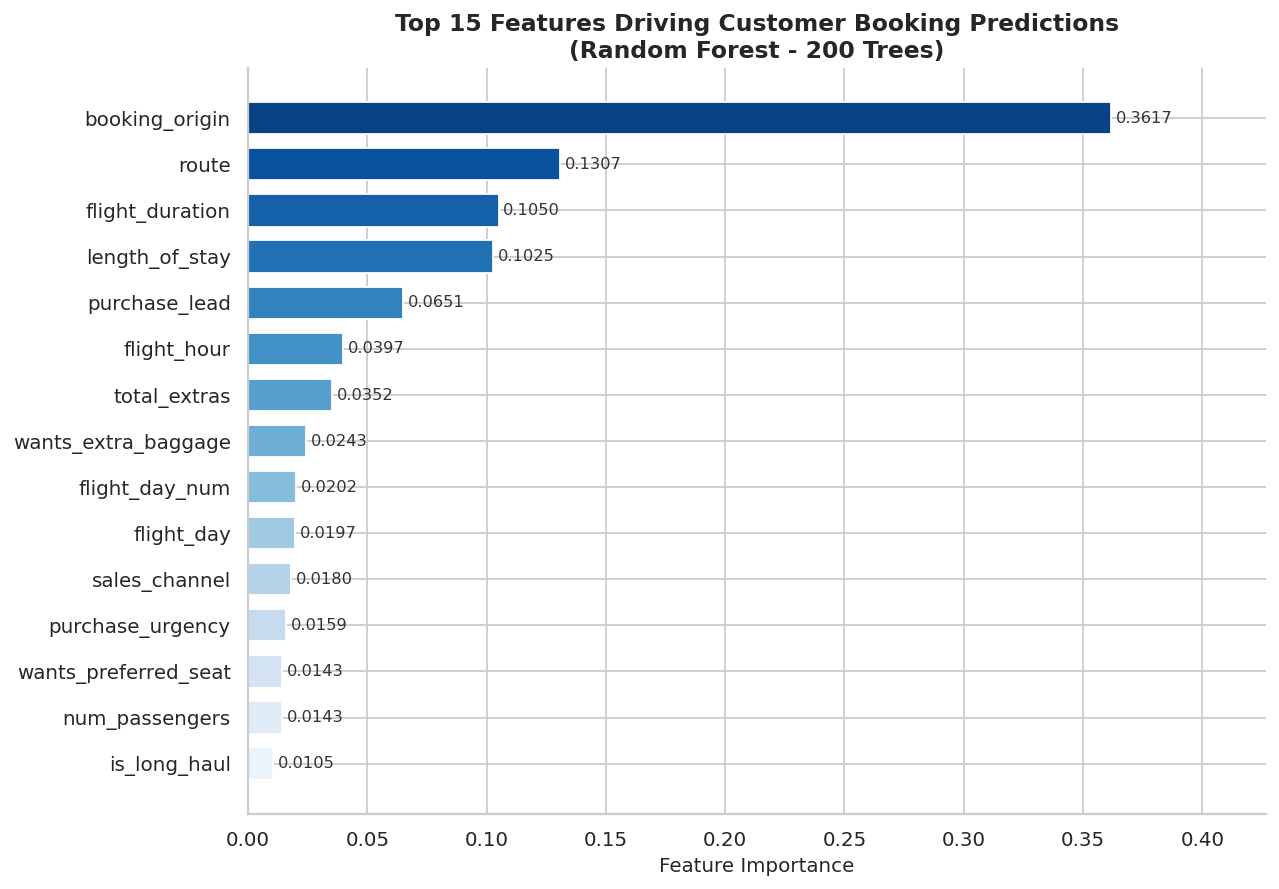

In [74]:
# Feauture importance

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    "Feature": x.columns, "Importance": importances
}).sort_values("Importance", ascending = False).reset_index(drop = True)

# Horizontal Bar Chart
top_n = 15
plot_data = feat_df.head(top_n)

fig, ax = plt.subplots(figsize = (10, 7))

colors = sns.color_palette("Blues_r", top_n)
bars = ax.barh(
    plot_data["Feature"][ : : -1],
    plot_data["Importance"][ : : -1],
    color = colors[ : : -1],
    edgecolor = "white",
    height = 0.7
)

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.002, bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}", va = "center", ha = "left", fontsize = 9, color = "#333"
    )

ax.set_xlabel("Feature Importance", fontsize = 11)
ax.set_title(
    f"Top {top_n} Features Driving Customer Booking Predictions\n"
    f"(Random Forest - {rf_model.n_estimators} Trees)",
    fontsize = 13, fontweight = "bold"
)
ax.set_xlim(0, plot_data["Importance"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

This is the most business relevant output. In other words, we endaover to find "Which factors most influence whether a customer books?"

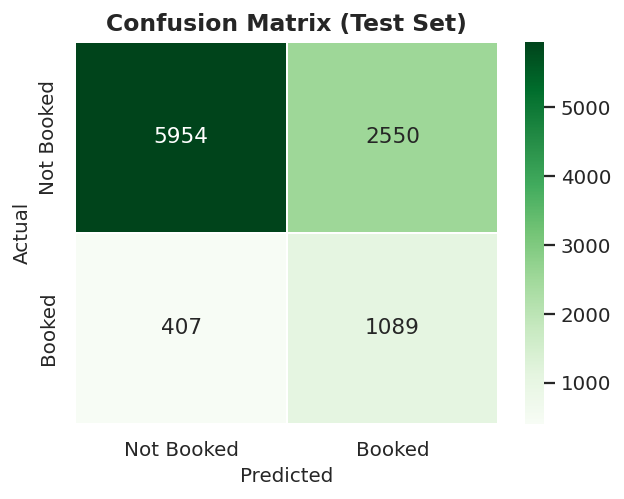

------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

  Not Booked       0.94      0.70      0.80      8504
      Booked       0.30      0.73      0.42      1496

    accuracy                           0.70     10000
   macro avg       0.62      0.71      0.61     10000
weighted avg       0.84      0.70      0.74     10000

------------------------------------------------------------
ROC AUC Score: 0.77


In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,
                                                    stratify = y, random_state = 42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)
y_prob = rf_model.predict_proba(x_test)[ : , 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize = (5, 4))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Greens", linewidths = 1,
    xticklabels = ["Not Booked", "Booked"], yticklabels = ["Not Booked", "Booked"])
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title("Confusion Matrix (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Classification Report
print("-" * 60)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names = ["Not Booked", "Booked"]))
print("-" * 60)
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

In [ ]:
# Finally

***I WOULD LIKE TO EXPRESS MY SINCERE GRATITUDE FOR YOUR TIME AND CONSIDERATION***

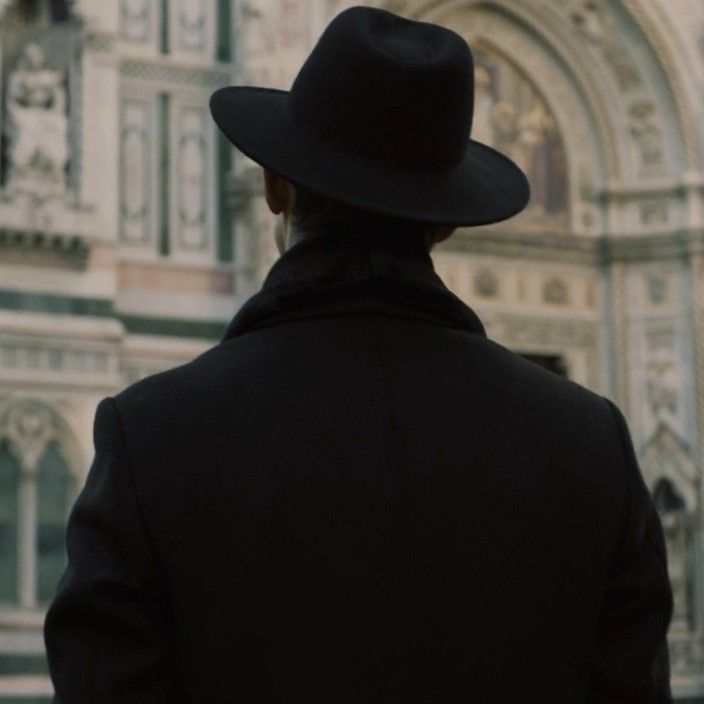